
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 1 <br>
</div>


---



### Full Name : Nazanin Yousefi
### Student Number : 401110172

## Introduction

In this assignment, we are going to investigate some of the basic methods of image enhancement.

## Section 1: Image Enhancement

Importing necessary Libraries. You cannot import and use any other libraries

In [31]:
# Do not modify this cell
import cv2
import numpy as np
import matplotlib.pylab as plt

import os # I imported this because i want to store results in directory related, thats more orginized

### Q1: Intensity Enhancement


In this question, you will implement some of the intensity processing functions and apply them on a given image. In the final part, you will be asked to use these functions to enhance the intensity of a given image.

<ol>
<li>
 <b>Negative Transform :</b> $y=255-x$

 <li>
 <b>Log Transform :</b> $y=\frac{255 \log(1+ \alpha x)}{\log(1+255 \alpha)}$

 <li>
 <b>Gamma Transform :</b> $y=255(\frac{x}{255})^{\gamma}$

 </ol>

In the following cells, complete the functions for

In [32]:

def negative_transform(img: np.ndarray):
  # TODO
        return 255 - img

In [33]:
def log_transform(img: np.ndarray, alpha):
  # TODO
        return (255 * np.log(1 + alpha * img) / np.log(1 + 255 * alpha)).astype(np.uint8)

In [34]:
def gamma_transform(img: np.ndarray, gamma):
  # TODO
        return (255 * (img / 255) ** gamma).astype(np.uint8)

Now, apply these transformations on `Q1-input1.jpg` (on RGB channels) and save the output images in `Q1-output-neg.jpg`, `Q1-output-log.jpg` and `Q1-output-gamma.jpg`, respectively. You can set $\alpha$ and $\gamma$ whatever you want, but effect on the intensity of the image should be noticable.

In [35]:

img =cv2.imread('Q1-input1.jpg')
# TODO: apply the transformations and save the results

results_dir = "Q1-outputs"
os.makedirs(results_dir, exist_ok=True)


neg_img = negative_transform(img)
log_img = log_transform(img, alpha=0.1) 
gamma_img = gamma_transform(img, gamma=1.5) 

# # Save the output images
# cv2.imwrite("Q1-output-neg.jpg", neg_img)
# cv2.imwrite("Q1-output-log.jpg", log_img)
# cv2.imwrite("Q1-output-gamma.jpg", gamma_img)

cv2.imwrite(os.path.join(results_dir, "Q1-output-neg.jpg"), neg_img)
cv2.imwrite(os.path.join(results_dir, "Q1-output-log.jpg"), log_img)
cv2.imwrite(os.path.join(results_dir, "Q1-output-gamma.jpg"), gamma_img)


True

In [15]:

img =cv2.imread('Q1-input1.jpg')
# TODO: apply the transformations and save the results

results_dir = "Q1-outputs"
os.makedirs(results_dir, exist_ok=True)


neg_img = negative_transform(img)
log_img = log_transform(img, alpha=0.1) 
gamma_img = gamma_transform(img, gamma=1.5) 

# # Save the output images
# cv2.imwrite("Q1-output-neg.jpg", neg_img)
# cv2.imwrite("Q1-output-log.jpg", log_img)
# cv2.imwrite("Q1-output-gamma.jpg", gamma_img)

cv2.imwrite(os.path.join(results_dir, "Q1-output-neg.jpg"), neg_img)
cv2.imwrite(os.path.join(results_dir, "Q1-output-log.jpg"), log_img)
cv2.imwrite(os.path.join(results_dir, "Q1-output-gamma.jpg"), gamma_img)


True

Finally, use the functions you implemented to enhance the intensity of `Q1-input2.jpg`. You may use any of the functions in anyway you desire. Your final score on the question depends on the quality of the output. Save the output image as `Q1-output-enhanced.jpg`.

In [43]:
img =cv2.imread('Q1-input2.jpg')
# TODO: enhance the intensity of the input image

# neg_img = negative_transform(img)
# log_img = log_transform(img, alpha=0.1) 
# gamma_img = gamma_transform(img, gamma=1.5) 

# cv2.imwrite(os.path.join(results_dir, "Q1t-output-neg.jpg"), neg_img)
# cv2.imwrite(os.path.join(results_dir, "Q1t-output-log.jpg"), log_img)
# cv2.imwrite(os.path.join(results_dir, "Q1t-output-gamma.jpg"), gamma_img)

log_img1 = log_transform(img, alpha=0.1) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log-0.1.jpg"), log_img1)
log_img3 = log_transform(img, alpha=0.3) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log-0.3.jpg"), log_img3)
log_img5 = log_transform(img, alpha=0.5) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log-0.5.jpg"), log_img5)
log_img2 = log_transform(img, alpha=0.2) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log-0.2.jpg"), log_img2)

gamma_img = gamma_transform(log_img1, gamma=1.5) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log1-gamma1-5.jpg"), gamma_img)
gamma_img = gamma_transform(log_img2, gamma=1.5) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log2-gamma1-5.jpg"), gamma_img) # this looks better
cv2.imwrite(os.path.join(results_dir, "Q1-output-enhanced.jpg"), gamma_img)

gamma_img = gamma_transform(log_img2, gamma=1.45) 
cv2.imwrite(os.path.join(results_dir, "Q1-output-log2-gamma1-45.jpg"), gamma_img)




True

### Q2: Histogram Specification


In this question, we will implement histogram specification for intensity enhancement.

Complete the following code to specify the histogram of the input image, with a given histogram `hist1`, to target histogram `hist2`.

**Note**: Assume that the input image has only one channel, i.e, it is a $H \times W$ numpy array.

In [48]:
def histogram_specification(img: np.ndarray, hist1: np.ndarray, hist2: np.ndarray):
  # TODO : implement histogram specification
    # first lets normalize the histograms -> create probability distribution
    hist1 = hist1 / np.sum(hist1)  #input histogram
    hist2 = hist2 / np.sum(hist2)   # output histogram

    #then cumulative distribution functions
    cdf1 = np.cumsum(hist1) 
    cdf2 = np.cumsum(hist2) 

    #creating a mapping from input pixel values to target pixel values
    mapping = np.zeros(256, dtype=np.uint8)  # Mapping for 0-255 intensity values
    for i in range(256):
        # we will look for the closest value in cdf2 for each value in cdf1 and map
        idx = np.argmin(np.abs(cdf2 - cdf1[i]))
        mapping[i] = idx
    
    # apply the mapping to the input image
    transformed_img = mapping[img]
    
    return transformed_img

To test the above code, open `Q2-input1.jpg` and `Q2-input2.jpg`, and convert the histogram of the first one to the second one. Save the resulting image as `Q2-output.jpg`. The aim of specifying the histograms is to enhance the first image, so your score depends on the quality of your result.

In [51]:
img1=cv2.imread('Q2-input1.jpg')
img2=cv2.imread('Q2-input2.jpg')
# TODO: Apply histogram specification

results_dir = "Q2-outputs"
os.makedirs(results_dir, exist_ok=True)

# we can have histograms of images using np.histogram method
hist1, _ = np.histogram(img1, bins=256, range=(0, 256))
hist2, _ = np.histogram(img2, bins=256, range=(0, 256))


transformed_img1 = histogram_specification(img1, hist1, hist2)
cv2.imwrite(os.path.join(results_dir, "Q2-output.jpg"),  transformed_img1)

transformed_img1 = histogram_specification(img1, hist1, hist2)
cv2.imwrite(os.path.join(results_dir, "Q2-output.jpg"),  transformed_img1) 
# the result seems ok but i would like too have color correction too but we skip it for now

# we could represnt the images using plt
# plt.figure(figsize=(15, 5))

# plt.subplot(1, 3, 1)
# plt.title('Input Image 1')
# plt.imshow(img1, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 3, 2)
# plt.title('Input Image 2')
# plt.imshow(img2, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 3, 3)
# plt.title('Transformed Image')
# plt.imshow(transformed_img, cmap='gray')
# plt.axis('off')

# plt.show()

True

### Q3: Color Processing

In image `Q3-input.jpg`, change the color of the flowers red, blue and yellow to violet, pink and orange respectively. Save the result as `Q3-output.jpg`. Your score of this question depends on the quality of the output image.

In [75]:
img=cv2.imread('Q3-input.jpg')
# TODO: change the colors
results_dir = "Q3-outputs"
os.makedirs(results_dir, exist_ok=True)

# we need the image to br HSV color space
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


# then we definr color ranges so that we change and stuff we need it
# red has two ranges: near 0 and near 180
red_lower1 = np.array([0, 50, 50])    # Lower range for red (0-10 degrees) 
red_upper1 = np.array([5, 255, 255]) # 5 works better for sunset sky here
red_lower2 = np.array([160, 50, 50])  # Upper range for red (160-180 degrees)
red_upper2 = np.array([180, 255, 255])

blue_lower = np.array([100, 50, 50])  # Blue (100-130 degrees)
blue_upper = np.array([130, 255, 255])

yellow_lower = np.array([13, 50, 50]) # Yellow (20-40 degrees) # 13 was more smooth
yellow_upper = np.array([40, 255, 255])


# creating mask for each color
mask_red1 = cv2.inRange(hsv_img, red_lower1, red_upper1)
mask_red2 = cv2.inRange(hsv_img, red_lower2, red_upper2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)  # Combine the two red ranges

mask_blue = cv2.inRange(hsv_img, blue_lower, blue_upper)
mask_yellow = cv2.inRange(hsv_img, yellow_lower, yellow_upper)

# now we will define target huese we need to use for Q3
violet_hue = 147  # Violet (around 150 degrees) # 147 seems better for me
pink_hue = 163    # Pink (around 165 degrees)
orange_hue = 12    # Orange (around 15 degrees) -> 15 was not orange-ish enough

# modifiying the image
hsv_img_modified = hsv_img.copy()
# Red -> Violet
hsv_img_modified[:, :, 0][mask_red == 255] = violet_hue

# Blue -> Pink
hsv_img_modified[:, :, 0][mask_blue == 255] = pink_hue

# Yellow -> Orange
hsv_img_modified[:, :, 0][mask_yellow == 255] = orange_hue

# converting back to BGR
output_img = cv2.cvtColor(hsv_img_modified, cv2.COLOR_HSV2BGR)

cv2.imwrite(os.path.join(results_dir,"Q3-output.jpg"), output_img)

True

## Section 2: Spatial Filters

### Q4: Blurring

In this question, you are going to implement a function to blur a given image using a specified method. Your function should support box filter, gaussian filter and median filter. It is permitted to use `opencv` to perform the bluring.

In [84]:
def blur(img: np.ndarray, kernel_size: int, filter: str):
  # TODO: implement blurring for box filter, Gaussian Blurring and median blurring

    if filter == 'box':
        # Box filter using cv2.blur
        blurred_img = cv2.blur(img, (kernel_size, kernel_size))
    
    elif filter == 'gaussian':
        # Gaussian filter using cv2.GaussianBlur
        # Let OpenCV compute sigma automatically (sigma=0)
        blurred_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sigmaX=0)
    
    elif filter == 'median':
        # Median filter using cv2.medianBlur
        blurred_img = cv2.medianBlur(img, kernel_size)
    
    return blurred_img

Test your code with kernel size $k=3, 11, 25$ for each of filters on `Q4-input.jpg`. Save the output images with the following format:
<ul>
<li> Box filter with kernel size $k=3, 11, 25$ as Q4-output-box3.jpg, Q4-output-box11.jpg and Q4-output-box25.jpg.

<li> Gaussian filter with kernel size $k=3, 11, 25$ as Q4-output-gauss3.jpg, Q4-output-gauss11.jpg and Q4-output-gauss25.jpg (you can set $\sigma$ whaever you wish, but blurring should be observable).

<li> Median filter with kernel size $k=3, 11, 25$ as Q4-output-med3.jpg, Q4-output-med11.jpg and Q4-output-med25.jpg.
</ul>

In [85]:
img=cv2.imread('Q4-input.jpg')
# TODO: Apply the filters

results_dir = "Q4-outputs"
os.makedirs(results_dir, exist_ok=True)

kernel_sizes = [3, 11, 25]

filters = ['box', 'gaussian', 'median']
for filter_type in filters:
    for k in kernel_sizes:
        blurred_img = blur(img, k, filter_type)
        
        # generate the output filename
        output_filename = f'Q4-output-{filter_type}{k}.jpg'
        
        # Save the result
        cv2.imwrite(os.path.join(results_dir,output_filename), blurred_img)
        print(f"Saved: {output_filename}")

Saved: Q4-output-box3.jpg
Saved: Q4-output-box11.jpg
Saved: Q4-output-box25.jpg
Saved: Q4-output-gaussian3.jpg
Saved: Q4-output-gaussian11.jpg
Saved: Q4-output-gaussian25.jpg
Saved: Q4-output-median3.jpg
Saved: Q4-output-median11.jpg
Saved: Q4-output-median25.jpg


### Q5: Sharpening

In this question, you are going to sharpen a given image using Gaussian Filter.


Let $f$ be the source image and $g$ be the Gaussian kernel, then $f*g$ is the convolution of the image with this kernel, which results in a blurred image.

To sharpen the image, we can generate an unsharp mask by subtracting the blurred image from the original image:
$$m=f-f*g$$
This mask is a transparent image which has higher intensity on the edges of the original image. Now we may add this mask with a weight $\alpha$ to sharpen the original image:
$$f'=f+ \alpha m$$

First, complete the following function to generate a Gaussian kernel with a given size and $\sigma$. A $(2k+1) \times (2k+1)$ Gaussian kernel has the value $e^{\frac{-(x^2+y^2)}{2 \sigma^2}}$ at point $(x,y)$ (Center of the kernel has coordinates $(0,0)$, and we have $x,y \in [-k,k]$). You should also normalize the kernel (sum of the entries should app up to 1)

In [101]:
def gaussian_kernel(kernel_size: int, sigma):
    # TODO: create the gaussian kernel with given size and sigma
    
    # k should have a vaue that, kernel_size = 2k + 1 helds
    k = (kernel_size - 1) // 2
    
    # Create an empty kernel
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    
    # for each position (x, y) we need to compute Gaussian values
    for x in range(-k, k + 1):
        for y in range(-k, k + 1):
            # Gaussian formula: exp(-(x^2 + y^2) / (2 * sigma^2))
            kernel[x + k, y + k] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # we should normalize the kernel -> sum of all entries is 1
    kernel_sum = np.sum(kernel)
    if kernel_sum != 0:
        kernel /= kernel_sum
    
    return kernel

Next, complete the following function to sharpen a given image and Gaussian kernel and $\alpha$. Your function should return both the sharpened image and the unsharp mask.

In [102]:
def gaussian_sharpen(img: np.ndarray, kernel: np.ndarray, alpha: float):
    # TODO: sharpen the image and return both the result and unsharp mask
    blurred_img = cv2.filter2D(img, -1, kernel)

    # Compute the unsharp mask (m = f - f * g)
    unsharp_mask = cv2.subtract(img, blurred_img)

    # Convert the unsharp mask to grayscale
    if len(img.shape) == 3:  # Color image -> 3
        unsharp_mask = cv2.cvtColor(unsharp_mask, cv2.COLOR_BGR2GRAY)
    else:  # Already grayscale
        unsharp_mask = unsharp_mask

    # Normalize the unsharp mask to the range [0, 255] for display
    unsharp_mask = cv2.normalize(unsharp_mask, None, 0, 255, cv2.NORM_MINMAX)
    unsharp_mask = unsharp_mask.astype(np.uint8)

    # Sharpen the image (f' = f + alpha * m)
    # if we have a colored image -> we need to apply the mask to each channel "colors channel"
    if len(img.shape) == 3:  # Color image
        # make the unsharp mask, as same size/shape as the image 
        unsharp_mask_color = cv2.cvtColor(unsharp_mask, cv2.COLOR_GRAY2BGR)
        sharpened_img = cv2.addWeighted(img, 1.0, unsharp_mask_color, alpha, 0.0)
    else:  # Grayscale image
        sharpened_img = cv2.addWeighted(img, 1.0, unsharp_mask, alpha, 0.0)

    return sharpened_img, unsharp_mask

Now to test your code, open `Q5-input.jpg` and sharpen it using the above function. Use a kernel size of 7 and choose a suitable value of $\sigma$ and $\alpha$ to get a desirable result. Save the sharpened image as `Q5-output-1.jpg` and the unsharp mask (grayscale image) as `Q5-output-2.jpg`. Your score on this part depends on the quality of the result.

In [103]:
img=cv2.imread('Q5-input.png')
# TODO: Sharpen the image and save the result and the unsharp mask
results_dir = "Q5-outputs"
os.makedirs(results_dir, exist_ok=True)

# Generate the Gaussian kernel
kernel_size = 7
sigma = 2.0
kernel = gaussian_kernel(kernel_size, sigma)

# Sharpen the image
alpha = 1.5
sharpened_img, unsharp_mask = gaussian_sharpen(img, kernel, alpha)

cv2.imwrite(os.path.join(results_dir, 'Q5-output-1.jpg'), sharpened_img)
cv2.imwrite(os.path.join(results_dir, 'Q5-unsharp.jpg'), unsharp_mask)

True

### Q6: Noise removal

## A) ACE Function
Implement the ACE function using ready-made functions for histogram equalization and padding. Apply the function with different grid sizes on ACE.jpg image and report the output for each one. Also specify which output is the best.

## B) CLAHE Function
Implement the CLAHE function and apply it to CLAHE.jpg image. Also specify which output is the best. In this function, test different values for the clipping threshold and grid size, analyze the effect of each, and output the best result.

## C) add_noise Function
Complete the add_noise function to add Gaussian or Salt-and-Pepper noise to the image. Using existing library functions is not allowed. Read the noise.tif image in grayscale and add Gaussian and Salt-and-Pepper noise separately to the image and display the output.

## D) denoise Function
Save the image resulting from adding Salt-and-Pepper noise and denoise it using an appropriate filter.

In [173]:
def ACE(image, gridSize):
  '''
  inputs:
    image (ndarray): input image
    gridSize (tuple): window size for calculating histogram equalization
  output:
    output (ndarray): improved image
  '''

  ###############################################
  ############# YOUR CODE GOES HERE #############
    
  pad_size = gridSize[0] // 2
  padded_image = np.pad(image, ((pad_size, pad_size), (pad_size, pad_size)), mode='reflect')

  rows, cols = image.shape
  equalized_image = np.zeros_like(image, dtype=np.float32)
  counts = np.zeros_like(image, dtype=np.float32)

  for i in range(rows):
    for j in range(cols):
      block = padded_image[i:i+gridSize[0], j:j+gridSize[1]]

      # Apply Gaussian blur to smooth the block before equalization
      blurred_block = cv2.GaussianBlur(block, (5, 5), 0)

      equalized_block = cv2.equalizeHist(blurred_block).astype(np.float32)

      block_rows = min(gridSize[0], rows - i)
      block_cols = min(gridSize[1], cols - j)

      equalized_image[i:i+block_rows, j:j+block_cols] += equalized_block[:block_rows, :block_cols]
      counts[i:i+block_rows, j:j+block_cols] += 1

  equalized_image = (equalized_image / counts).astype(np.uint8)
  output = equalized_image

  ###############################################
  return output


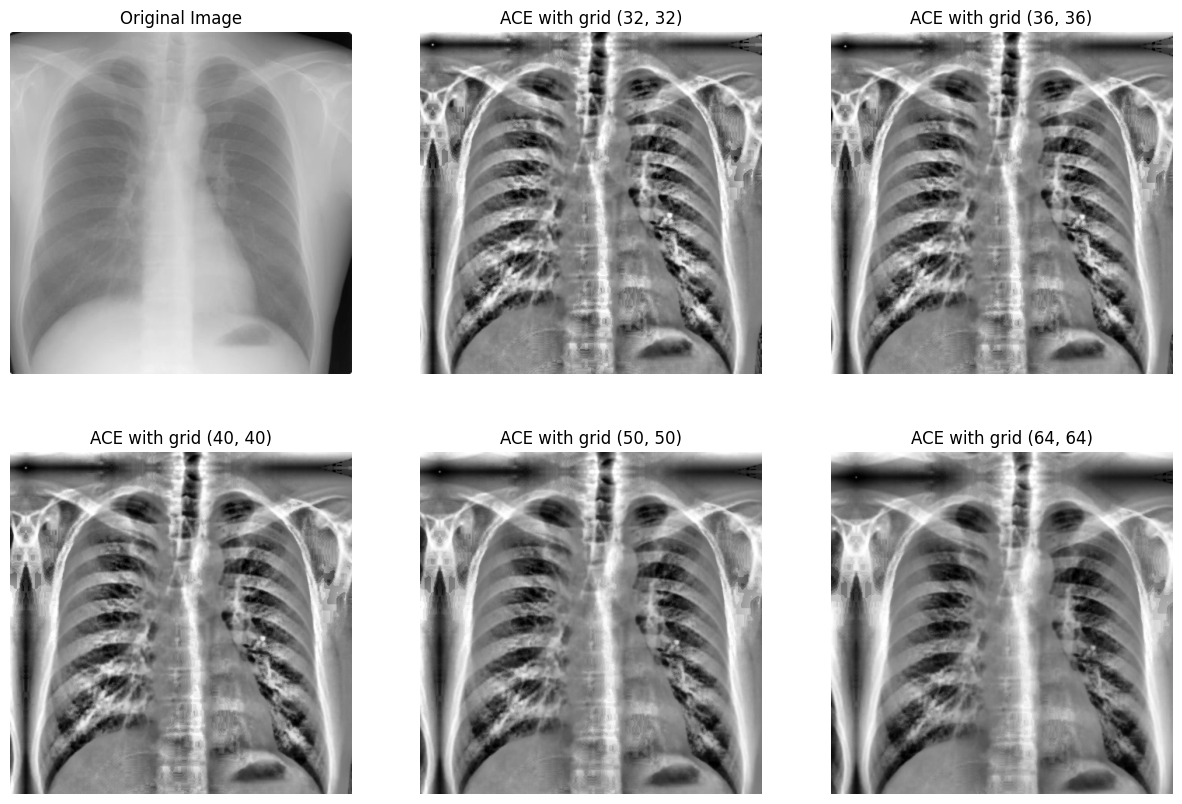

Based on visual inspection, the best grid size is: (36, 36)


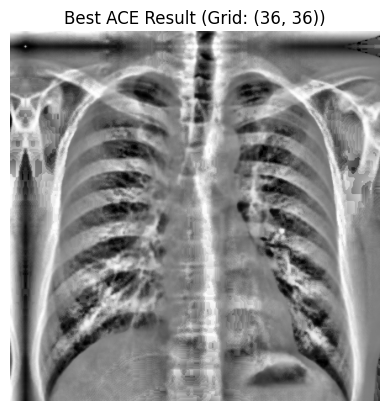

True

In [174]:
# img = cv2.imread('ACE.jpg')
img = cv2.imread('ACE.jpg', cv2.IMREAD_GRAYSCALE)  # Load in grayscale
output_dir = "Q6 outputs"
os.makedirs(output_dir, exist_ok=True)

# grid_sizes = [(8, 8), (16, 16), (32, 32)]
# grid_sizes = [(2, 2), (4,4), (6, 6),(8, 8), (10, 10), (12, 12), (14, 14),(18, 18), (20, 20), (23, 23)]
# grid_sizes = [(32, 32), (64, 64), (128, 128)]
# grid_sizes = [(2, 2), (3, 3), (4, 4)]

# grid_sizes = [(16, 16), (20, 20), (24, 24)]
# grid_sizes = [(16, 16), (14, 14), (12, 12),(18,18),(20,20)]
# maybe we need larger grids
# grid_sizes = [(32, 32), (64, 64), (128, 128),(100,100),(40,40)]

grid_sizes = [(32, 32), (36, 36), (40, 40),(50,50),(64,64)]






results = {}

num_images = len(grid_sizes) + 1  # Original image + all processed images
cols = 3  
rows = (num_images + cols - 1) // cols  

plt.figure(figsize=(15, 5 * rows)) 

plt.subplot(rows, cols, 1)  
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

for i, size in enumerate(grid_sizes):
  result = ACE(img.copy(), size)
  results[size] = result

  plt.subplot(rows, cols, i + 2)  
  plt.imshow(result, cmap='gray')
  plt.title(f"ACE with grid {size}")
  plt.axis('off')

plt.savefig(os.path.join(output_dir, "ace_results_adjusted.png"))
plt.show()

#######################################################
# best_grid_size = (12, 12) 
# best_grid_size = (3, 3) 
# best_grid_size = (8, 8) 
# best_grid_size = (16, 16) 
# final best result
best_grid_size = (36, 36) 



print(f"Based on visual inspection, the best grid size is: {best_grid_size}")

best_result = results[best_grid_size] 

best_result_rgb = cv2.cvtColor(best_result, cv2.COLOR_BGR2RGB) 

plt.figure()
plt.imshow(best_result_rgb)
plt.title(f"Best ACE Result (Grid: {best_grid_size})")
plt.axis('off')
plt.savefig(os.path.join(output_dir, f"ace_best_result_grid_{best_grid_size[0]}x{best_grid_size[1]}.png"))
plt.show()

cv2.imwrite(os.path.join(output_dir, "ace_best_result_opencv.jpg"), best_result) 
###############################################

In [126]:
def CLAHE(image, gridSize, threshold):
  '''
  inputs:
    image (ndarray): input image
    gridSize (tuple): window size for calculating histogram equalization
    threshold (int): threshold for contrast limiting
  output:
    output (ndarray): improved image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output = ...

  ###############################################
  return output

In [ ]:
###############################################
######## PLOT INPUT AND OUTPUT IMAGES##########


###############################################

In [ ]:
def add_noise(image, noise_type, args):

  '''
  inputs:
    image (ndarray): This is the input image represented as a NumPy array.

    noise_type (int): This parameter specifies which type of noise to add.
    It can take the following values:
    0: Gaussian Noise
    1: Salt-and-Pepper Noise

    args (list): A list of arguments that contains additional parameters needed for each noise mode.The required arguments are different depending on the noise_type.

  output:
    output_image (ndarray): noisy image.


  1. Gaussian Noise (noise_type = 0):

    Arguments (passed via args):
    mean: The mean of the Gaussian distribution (center value of noise).
    sigma: the standard deviation (sigma) of the Gaussian distribution.

    How it works:
    Generate Gaussian noise with this mean and sigma that has the same shape as the input image.
    Add this noise to the original image to create the noisy image.

  2. Salt-and-Pepper Noise (noise_type = 1):

    Arguments (passed via args):
    prob: The probability of a pixel being changed to Salt, Pepper, or staying unchanged.

    How it works:
    For each pixel in the image, generate a random number.
    If the random number is less than prob, change the pixel value to Salt (255).
    If the random number is greater than 1 - prob, change the pixel value to Pepper (0).
    Otherwise, leave the pixel unchanged.

  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  if noise_type == 0: # Gaussian Noise
    ...

  else: # Salt-and-Pepper Noise
    ...

  ###############################################
  return output


In [ ]:
###############################################
######## PLOT INPUT AND OUTPUT IMAGES##########


###############################################

In [ ]:
def denoise(noisy_image):

  '''
  input:
    noisy_image (ndarray): the noisy image

  output:
    output_image (ndarray): denoised image

  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output = ...

  ###############################################
  return output



In [ ]:
###############################################
######## PLOT INPUT AND OUTPUT IMAGES##########


###############################################